In [1]:
import pandas as pd

df = pd.read_csv('./save_annotations_df_Olivine.csv')

In [2]:
feret_mins = df['feret_min_mm']
feret_maxes = df['feret_max_mm']
touch_edges = df['touch_edge']

In [3]:
import matplotlib.pyplot as plt

def plot_aspectRatio_histograms_and_scatter(feret_mins, feret_maxes, touch_edges):
    # Define the bins for Feret minimum values
    bins = [(0.01, 0.075), (0.075, 0.105), (0.105, 0.15), (0.15, 0.25), (0.25, 0.425), (0.425, 0.85)]
    titles = [
        'Aspect Ratio - 0.01mm to 0.075mm',
        'Aspect Ratio - 0.075mm to 0.105mm',
        'Aspect Ratio - 0.105mm to 0.15mm',
        'Aspect Ratio - 0.15mm to 0.25mm',
        'Aspect Ratio - 0.25mm to 0.425mm',
        'Aspect Ratio - 0.425mm to 0.85mm'
    ]
    
    # Create subplots: 2 rows (1 for histograms, 1 for scatter plots)
    fig, axs = plt.subplots(2, len(bins), figsize=(20, 10))
    fig.suptitle("Histograms and Scatter Plots of Particle Attributes")
    
    # Loop through each bin and calculate aspect ratios
    for i, (lower, upper) in enumerate(bins):
        # Filter data based on the current bin and exclude particles touching edges
        bin_indices = [
            j for j, min_val in enumerate(feret_mins) 
            if lower <= min_val < upper and not touch_edges[j]
        ]
        bin_aspect_ratios = [feret_mins[j] / feret_maxes[j] for j in bin_indices]
        bin_feret_mins = [feret_mins[j] for j in bin_indices]
        bin_feret_maxes = [feret_maxes[j] for j in bin_indices]
        
        # Plot histogram for the current bin
        axs[0, i].hist(bin_aspect_ratios, bins=30, color='blue', alpha=0.7)
        axs[0, i].set_title(titles[i])
        axs[0, i].set_xlabel('Aspect Ratio')
        axs[0, i].set_ylabel('Frequency')

        # Set consistent x-axis ticks for histograms
        axs[0, i].set_xticks([x / 5 for x in range(0, 6)])  # Ticks from 0.0 to 1.0 in steps of 0.1
        
        # Plot scatter plot for the current bin
        axs[1, i].scatter(bin_feret_mins, bin_feret_maxes, alpha=0.7, color='green')
        axs[1, i].set_title(f'Feret Min vs Max - {titles[i]}')
        axs[1, i].set_xlabel('Feret Min')
        axs[1, i].set_ylabel('Feret Max')
    
    plt.tight_layout()
    # Save the figure as a PNG file
    # plt.savefig(f'{save_dir}/histogram_and_scatter_aspect_ratios.png')
    plt.show()

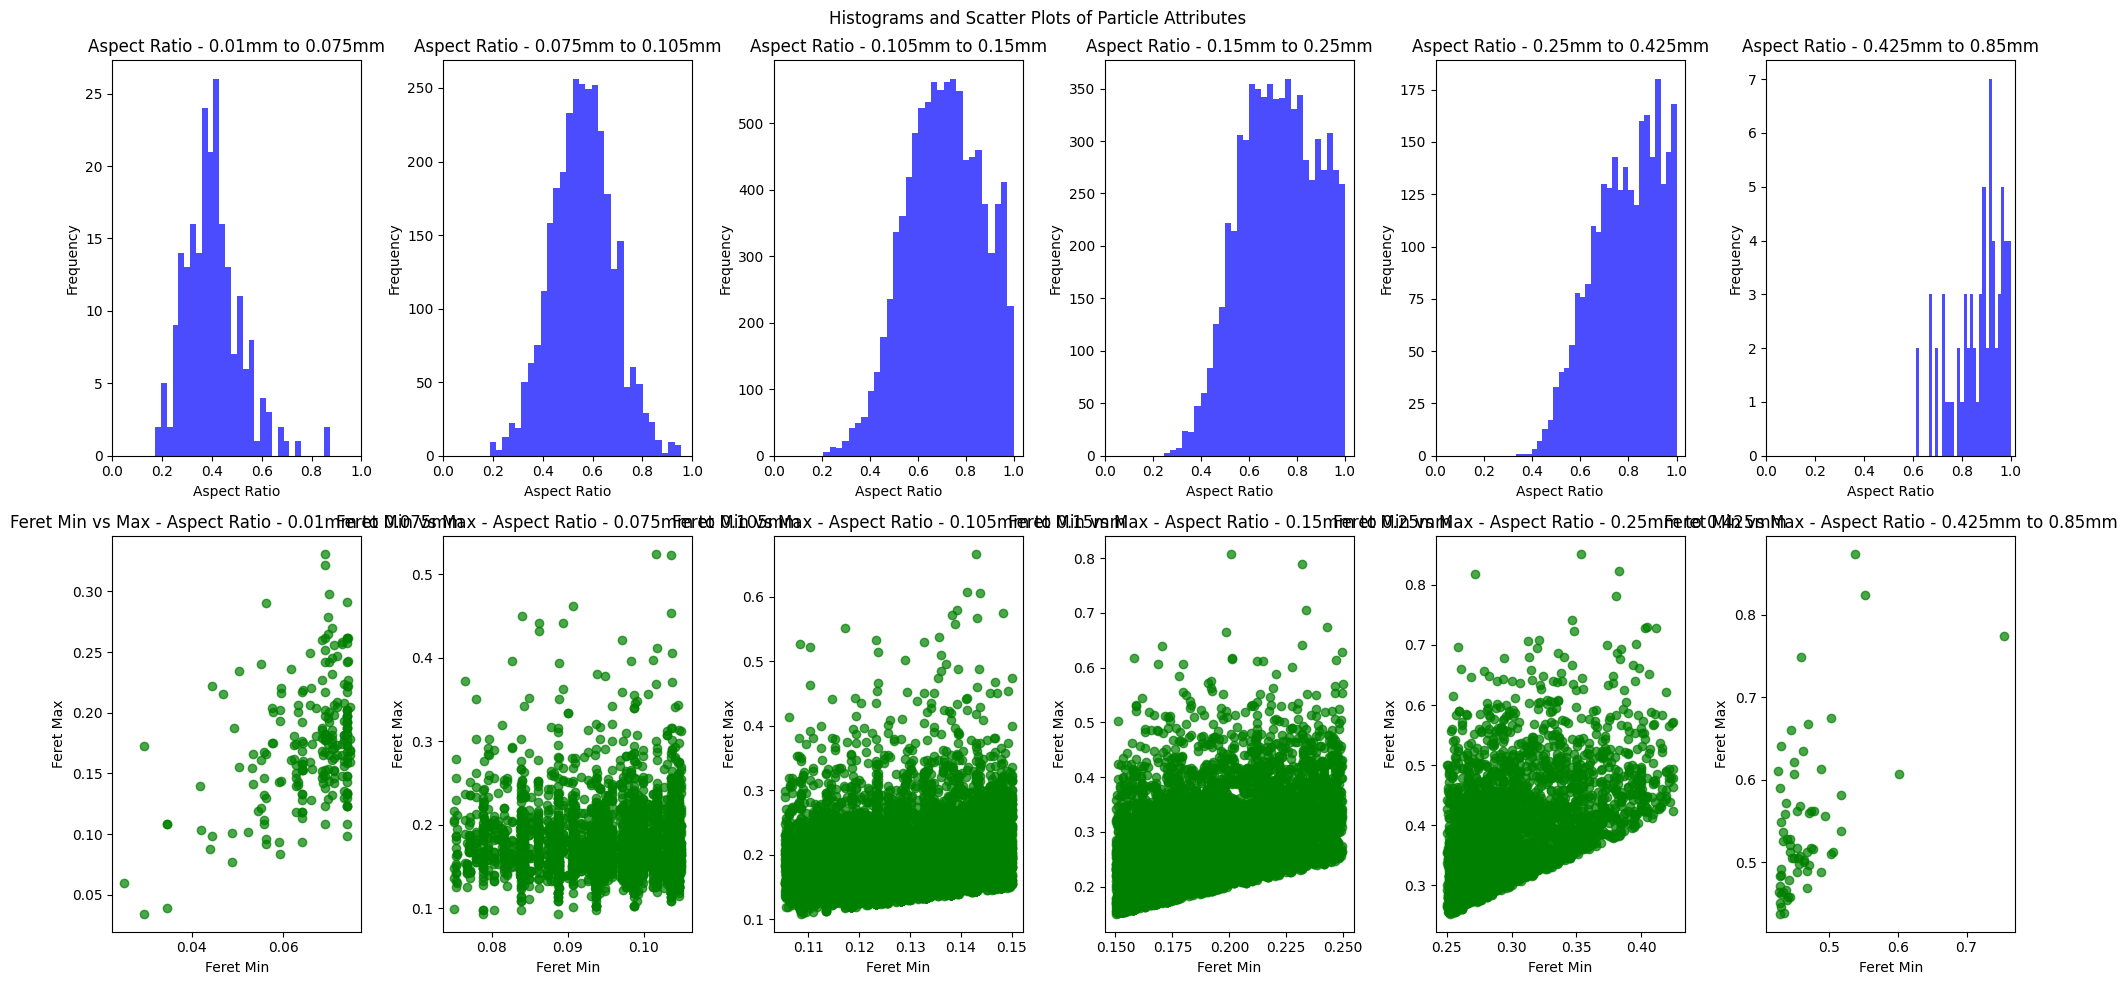

In [4]:
plot_aspectRatio_histograms_and_scatter(feret_mins, feret_maxes, touch_edges)

In [5]:
min(feret_mins)

0.0251471914665514

In [6]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import gaussian_kde

def estimate_third_dimension_probabilistic(feret_mins, feret_maxes, num_bins=50):
    """
    Estimate the third dimension probabilistically for grains of sand.

    Parameters:
        feret_mins (list): List of minimum dimensions observed in the profile.
        feret_maxes (list): List of maximum dimensions observed in the profile.
        num_bins (int): Number of bins to divide the range of feret_min.

    Returns:
        dict: A dictionary where keys are bin ranges and values are distributions of feret_max and feret_min.
    """
    # Calculate the range of feret_min
    min_feret_min = min(feret_mins)
    max_feret_min = max(feret_mins)
    
    # Create bins for feret_min
    bins = np.linspace(min_feret_min, max_feret_min, num_bins + 1)
    
    # Dictionary to store distributions for each bin
    bin_distributions = {}
    
    # Loop through each bin
    for i in range(len(bins) - 1):
        lower, upper = bins[i], bins[i + 1]
        
        # Filter grains that fall within the current bin
        bin_indices = [j for j, min_val in enumerate(feret_mins) if lower <= min_val < upper]
        bin_feret_maxes = [feret_maxes[j] for j in bin_indices]
        bin_feret_mins = [feret_mins[j] for j in bin_indices]
        
        bin_distributions[(lower, upper)] = {}
        
        # Calculate distribution for feret_max
        if len(bin_feret_maxes) > 1:
            try:
                bin_feret_maxes = np.array(bin_feret_maxes).reshape(-1, 1)
                kde_max = gaussian_kde(bin_feret_maxes.T)
                bin_distributions[(lower, upper)]['feret_max'] = kde_max
            except np.linalg.LinAlgError:
                unique_value = bin_feret_maxes[0]
                bin_distributions[(lower, upper)]['feret_max'] = {'type': 'empirical', 'value': unique_value, 'count': len(bin_feret_maxes)}
        elif len(bin_feret_maxes) == 1:
            unique_value = bin_feret_maxes[0]
            bin_distributions[(lower, upper)]['feret_max'] = {'type': 'empirical', 'value': unique_value, 'count': len(bin_feret_maxes)}
        else:
            bin_distributions[(lower, upper)]['feret_max'] = None
        
        # Calculate distribution for feret_min
        if len(bin_feret_mins) > 1:
            try:
                bin_feret_mins = np.array(bin_feret_mins).reshape(-1, 1)
                kde_min = gaussian_kde(bin_feret_mins.T)
                bin_distributions[(lower, upper)]['feret_min'] = kde_min
            except np.linalg.LinAlgError:
                unique_value = bin_feret_mins[0]
                bin_distributions[(lower, upper)]['feret_min'] = {'type': 'empirical', 'value': unique_value, 'count': len(bin_feret_mins)}
        elif len(bin_feret_mins) == 1:
            unique_value = bin_feret_mins[0]
            bin_distributions[(lower, upper)]['feret_min'] = {'type': 'empirical', 'value': unique_value, 'count': len(bin_feret_mins)}
        else:
            bin_distributions[(lower, upper)]['feret_min'] = None
    
    return bin_distributions

def plot_distributions(bin_distributions):
    """
    Plot the distributions of feret_max and feret_min for each bin.

    Parameters:
        bin_distributions (dict): Dictionary of distributions for each bin.
    """
    fig, axs = plt.subplots(len(bin_distributions), 2, figsize=(10, len(bin_distributions) * 2))
    
    for i, ((lower, upper), distributions) in enumerate(bin_distributions.items()):
        for j, (dim, distribution) in enumerate(distributions.items()):
            if distribution is not None:
                if isinstance(distribution, dict) and distribution['type'] == 'empirical':  # Empirical distribution
                    unique_value = distribution['value']
                    count = distribution['count']
                    axs[i, j].bar([unique_value], [count], width=1.0, label=f'Bin: {lower:.2f} - {upper:.2f}')
                    axs[i, j].set_xlim(lower, upper)  # Set x-axis limits to bin range
                else:  # KDE distribution
                    # Generate x values for plotting
                    x = np.linspace(min(distribution.dataset[0]), max(distribution.dataset[0]), 1000).reshape(-1, 1)
                    y = distribution(x.T)  # Transpose x to match expected dimensions
                    axs[i, j].plot(x.flatten(), y, label=f'Bin: {lower:.2f} - {upper:.2f}')
                
                axs[i, j].set_title(f'Distribution of {dim.capitalize()} for Bin {lower:.2f} - {upper:.2f}')
                axs[i, j].set_xlabel(dim.capitalize())
                axs[i, j].set_ylabel('Density')
                axs[i, j].legend()
            else:
                axs[i, j].text(0.5, 0.5, f'No data for Bin {lower:.2f} - {upper:.2f}', 
                               horizontalalignment='center', verticalalignment='center')
                axs[i, j].set_title(f'Bin {lower:.2f} - {upper:.2f}')
    
    plt.tight_layout()
    plt.show()

In [7]:
bin_distros = estimate_third_dimension_probabilistic(feret_mins, feret_maxes, num_bins=25)
bin_distros

{(0.0251471914665514,
  0.05432373620788935): {'feret_max': <scipy.stats._kde.gaussian_kde at 0x7f631be299c0>, 'feret_min': <scipy.stats._kde.gaussian_kde at 0x7f631be2b490>},
 (0.05432373620788935,
  0.08350028094922729): {'feret_max': <scipy.stats._kde.gaussian_kde at 0x7f631be2b4c0>, 'feret_min': <scipy.stats._kde.gaussian_kde at 0x7f6320191de0>},
 (0.08350028094922729,
  0.11267682569056525): {'feret_max': <scipy.stats._kde.gaussian_kde at 0x7f631be2b250>, 'feret_min': <scipy.stats._kde.gaussian_kde at 0x7f6320191b40>},
 (0.11267682569056525,
  0.1418533704319032): {'feret_max': <scipy.stats._kde.gaussian_kde at 0x7f63201919f0>, 'feret_min': <scipy.stats._kde.gaussian_kde at 0x7f631bdfba30>},
 (0.1418533704319032,
  0.17102991517324115): {'feret_max': <scipy.stats._kde.gaussian_kde at 0x7f631bdfbb20>, 'feret_min': <scipy.stats._kde.gaussian_kde at 0x7f631bdfbb50>},
 (0.17102991517324115,
  0.20020645991457908): {'feret_max': <scipy.stats._kde.gaussian_kde at 0x7f631bdfbca0>, 'feret

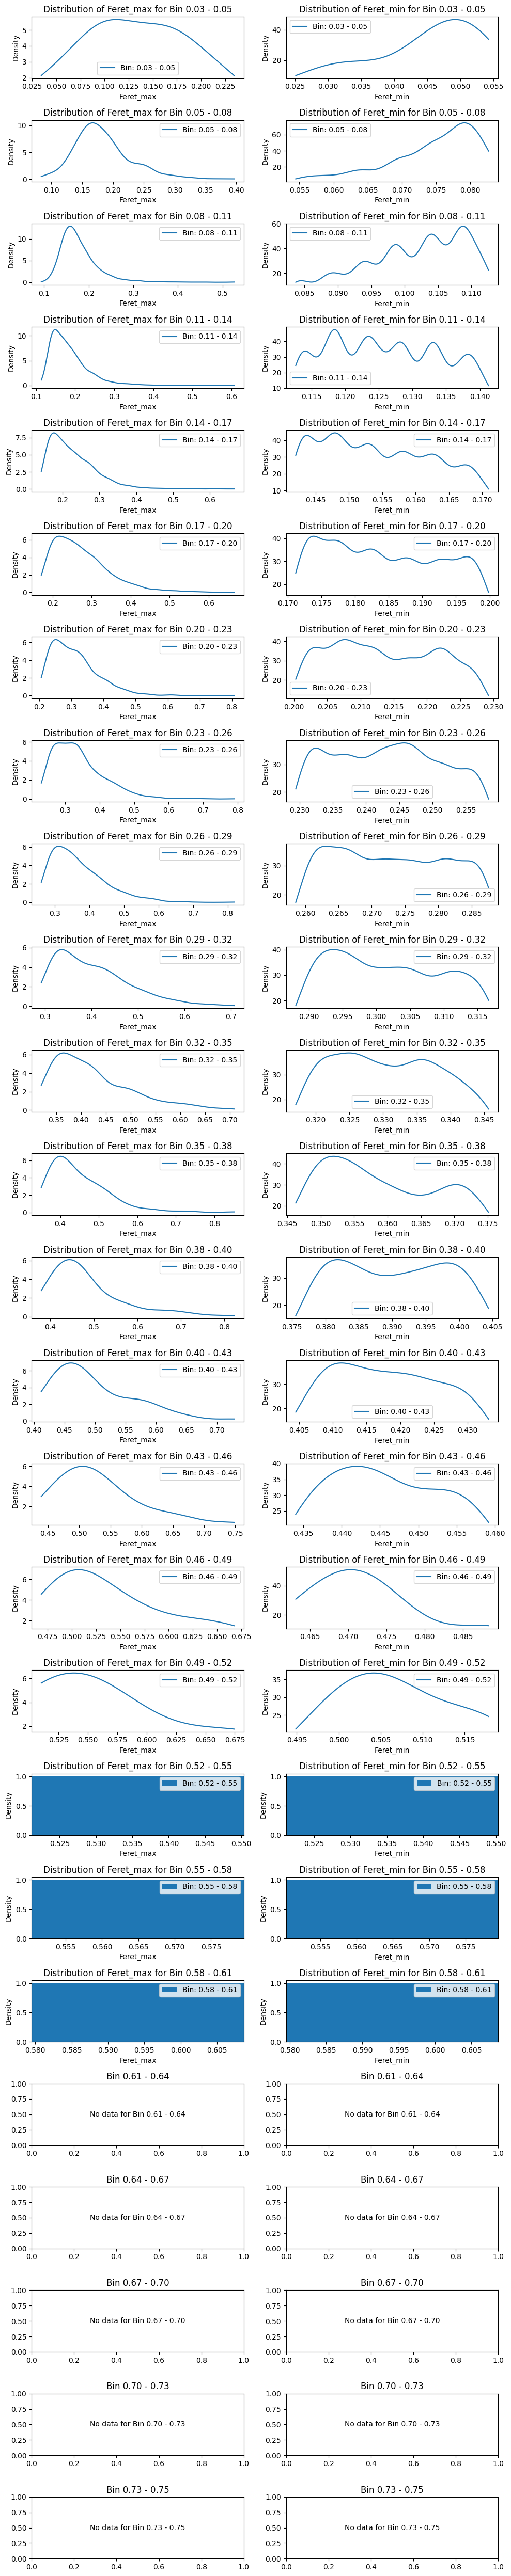

In [8]:
# Plot distributions
plot_distributions(bin_distros)

In [9]:
def estimate_third_dimension_probabilistic(feret_mins, feret_maxes, num_bins=50):
    """
    Estimate the third dimension probabilistically for grains of sand.

    Parameters:
        feret_mins (list): List of minimum dimensions observed in the profile.
        feret_maxes (list): List of maximum dimensions observed in the profile.
        num_bins (int): Number of bins to divide the range of feret_min.

    Returns:
        dict: A dictionary where keys are bin ranges and values are KDEs of combined dimension options.
    """
    # Calculate the range of feret_min
    min_feret_min = min(feret_mins)
    max_feret_min = max(feret_mins)
    
    # Create bins for feret_min
    bins = np.linspace(min_feret_min, max_feret_min, num_bins + 1)
    
    # Dictionary to store KDEs for each bin
    bin_distributions = {}
    
    # Loop through each bin
    for i in range(len(bins) - 1):
        lower, upper = bins[i], bins[i + 1]
        
        # Filter grains that fall within the current bin
        bin_indices = [j for j, min_val in enumerate(feret_mins) if lower <= min_val < upper]
        bin_feret_maxes = [feret_maxes[j] for j in bin_indices]
        bin_feret_mins = [feret_mins[j] for j in bin_indices]
        
        # Combine feret_max and feret_min options into a single dataset
        combined_dimensions = bin_feret_maxes + bin_feret_mins
        
        if len(combined_dimensions) > 1:
            # Apply Gaussian KDE to the combined dataset
            kde = gaussian_kde(combined_dimensions)
            bin_distributions[(lower, upper)] = kde
        else:
            # If insufficient data, store None
            bin_distributions[(lower, upper)] = None
    
    return bin_distributions

def estimate_third_dimension(fmin, bin_distributions):
    """
    Estimate the third dimension for a grain given feret_min and feret_max.

    Parameters:
        fmin (float): Observed feret_min for the grain.
        fmax (float): Observed feret_max for the grain.
        bin_distributions (dict): KDEs of combined dimension options for each bin.

    Returns:
        float: Estimated third dimension.
    """
    for bin_range, kde in bin_distributions.items():
        lower, upper = bin_range
        if lower <= fmin < upper and kde is not None:
            # Use the KDE to estimate the third dimension
            # For simplicity, return the mode (most probable value)
            x = np.linspace(min(kde.dataset[0]), max(kde.dataset[0]), 1000)  # Ensure x is 1D
            y = kde(x)
            return x[np.argmax(y)]
    
    return None  # If no matching bin is found

def plot_combined_distributions(bin_distributions):
    """
    Plot the combined KDE distributions for each bin.

    Parameters:
        bin_distributions (dict): KDEs of combined dimension options for each bin.
    """
    fig, axs = plt.subplots(len(bin_distributions), 1, figsize=(10, len(bin_distributions) * 2))
    
    for i, (bin_range, kde) in enumerate(bin_distributions.items()):
        lower, upper = bin_range
        if kde is not None:
            # Generate x values for plotting
            x = np.linspace(min(kde.dataset[0]), max(kde.dataset[0]), 1000)  # Ensure x is 1D
            y = kde(x)
            
            axs[i].plot(x, y, label=f'Bin: {lower:.2f} - {upper:.2f}')
            axs[i].set_title(f'Combined KDE for Bin {lower:.2f} - {upper:.2f}')
            axs[i].set_xlabel('Dimension')
            axs[i].set_ylabel('Density')
            axs[i].legend()
        else:
            axs[i].text(0.5, 0.5, f'No data for Bin {lower:.2f} - {upper:.2f}', 
                        horizontalalignment='center', verticalalignment='center')
            axs[i].set_title(f'Bin {lower:.2f} - {upper:.2f}')
    
    plt.tight_layout()
    plt.show()

In [10]:
bin_distros = estimate_third_dimension_probabilistic(feret_mins, feret_maxes, num_bins=25)
bin_distros

{(0.0251471914665514,
  0.05432373620788935): <scipy.stats._kde.gaussian_kde at 0x7f636c7966e0>,
 (0.05432373620788935,
  0.08350028094922729): <scipy.stats._kde.gaussian_kde at 0x7f636c797fd0>,
 (0.08350028094922729,
  0.11267682569056525): <scipy.stats._kde.gaussian_kde at 0x7f631bdd34f0>,
 (0.11267682569056525,
  0.1418533704319032): <scipy.stats._kde.gaussian_kde at 0x7f631bdd3220>,
 (0.1418533704319032,
  0.17102991517324115): <scipy.stats._kde.gaussian_kde at 0x7f636c797a30>,
 (0.17102991517324115,
  0.20020645991457908): <scipy.stats._kde.gaussian_kde at 0x7f62e5ce49a0>,
 (0.20020645991457908,
  0.22938300465591702): <scipy.stats._kde.gaussian_kde at 0x7f62e5e24790>,
 (0.22938300465591702,
  0.258559549397255): <scipy.stats._kde.gaussian_kde at 0x7f62e5ae8a90>,
 (0.258559549397255,
  0.28773609413859297): <scipy.stats._kde.gaussian_kde at 0x7f636c797b80>,
 (0.28773609413859297,
  0.31691263887993093): <scipy.stats._kde.gaussian_kde at 0x7f631be39c00>,
 (0.31691263887993093,
  0.

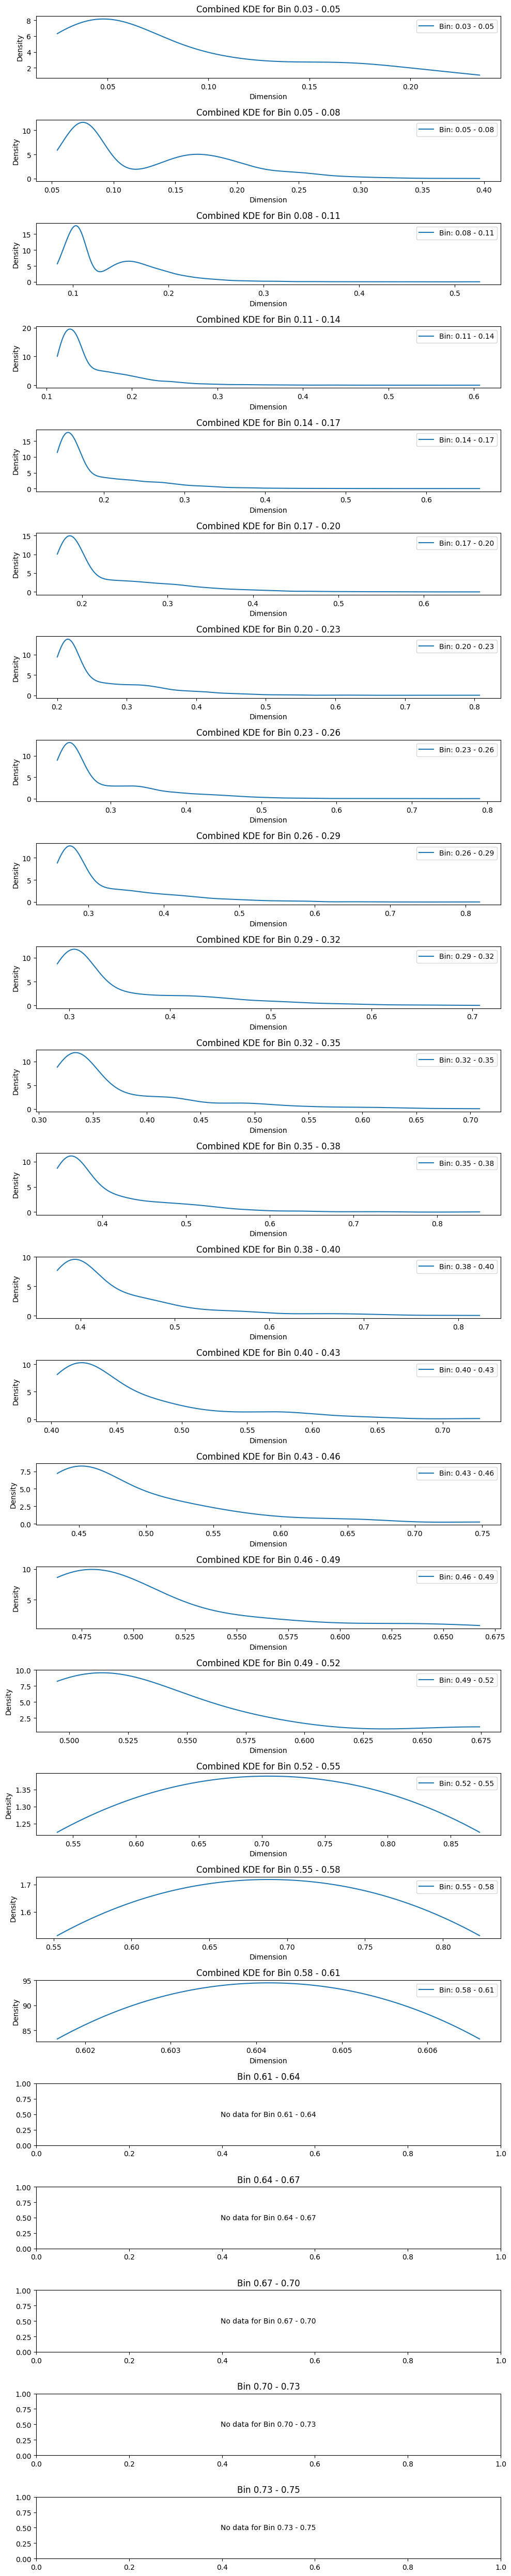

In [11]:
# Plot distributions
plot_combined_distributions(bin_distros)

In [12]:
df.head()

,Unnamed: 0,image_name,width,height,bbox,score,category_id,segmentation,touch_edge,sphericity,area,circle_radius,feret_min,feret_min_mm,feret_max,feret_max_mm,volume,ellip_volume,cumulative_volume,percentage_passing
0,21953,frame_0332,2448,2048,"[1299, 2, 1363, 29]",0.396392,0,"[[1325, 17], [1320, 13, 1319, 14, 1317, 14, 13...",False,0.125365,0.000778,9.013878,5.09902,0.025147,12.165525,0.059998,0.000159,0.000034,0.000034,0.000024
1,17726,frame_0571,2448,2048,"[1868, 2019, 1911, 2046]",0.215668,0,"[[1887, 2030, 1888, 2031, 1889, 2031, 1888, 20...",False,0.245255,0.000572,5.522681,6.00000,0.029591,7.000000,0.034522,0.000127,0.000017,0.000051,0.000036
2,10840,frame_1096,2448,2048,"[1281, 1169, 1330, 1216]",0.842172,0,"[[1282, 1181, 1282, 1199, 1283, 1200, 1282, 12...",False,0.068910,0.003162,24.505102,6.00000,0.029591,35.000000,0.172612,0.000633,0.000270,0.000321,0.000230
3,7441,frame_1424,2448,2048,"[1866, 385, 1911, 437]",0.937764,0,"[[1904, 423, 1904, 427], [1897, 419, 1896, 420...",False,0.072194,0.000669,11.011358,7.00000,0.034522,8.000000,0.039454,0.000197,0.000026,0.000348,0.000249
4,11038,frame_0706,2448,2048,"[1604, 1082, 1665, 1111]",0.211064,0,"[[1611, 1090, 1610, 1091, 1607, 1091, 1605, 10...",False,0.177969,0.002128,12.509996,7.00000,0.034522,22.000000,0.108499,0.000542,0.000140,0.000488,0.000350


In [14]:
# Assuming `estimate_third_dimension` can be modified to accept arrays:
from concurrent.futures import ProcessPoolExecutor
from tqdm import tqdm

# Define the worker function
def worker(value):
    return estimate_third_dimension(value, bin_distros)

# Extract the column to process
fmins = df['feret_min_mm']

# Use ProcessPoolExecutor for parallelization
with ProcessPoolExecutor() as executor:
    new_col_values = list(tqdm(executor.map(worker, fmins), total=len(fmins)))

# Assign the results back to the DataFrame
df['third_dim'] = new_col_values



 53%|███████████████████████████████████████████████████████████▉                                                     | 11840/22341 [10:46<09:33, 18.31it/s]


KeyboardInterrupt: 

In [ ]:
df['new_volume'] = 